<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Flatten, Add


In [ ]:
# --- Load Data ---
df = pd.read_csv('allDataMean.csv')
data = df[['allDataMean6']].values

In [ ]:

# --- Normalize ---
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
# --- Create Sequences ---
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
# --- Train-Test Split ---
split = int(len(X) * 0.8)
x_train = X[:split].reshape((-1, seq_length, 1))
x_test = X[split:].reshape((-1, seq_length, 1))
y_train, y_test = y[:split], y[split:]

In [ ]:
# --- ResNet-style CNN Model ---
input_layer = Input(shape=(seq_length, 1))
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(input_layer)
res = x
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Conv1D(64, kernel_size=3, padding='same')(x)
x = Add()([x, res])  # Residual connection
x = Flatten()(x)
output = Dense(1)(x)
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='mse')

In [ ]:
# --- Train ---
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1)

Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 7.0565e-04 - val_loss: 1.7615e-07
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - loss: 8.0735e-08 - val_loss: 2.0662e-07
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 2.6119e-06 - val_loss: 8.7405e-08
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 1.2646e-06 - val_loss: 7.3996e-08
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 3.8390e-07 - val_loss: 1.2499e-06
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 6.1451e-07 - val_loss: 9.1560e-06
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 3.7768e-07 - val_loss: 2.6536e-07
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 7.1721e-07 - val_loss: 3.0881e-07
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 40s 9ms/step - loss: 3.7607e-07 - val_loss: 1.6618e-06
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 1.1160e-06 - val_loss: 7.5119e-08
Epoch 11/50
2075/2075

In [ ]:
# --- Predict ---
y_pred = model.predict(x_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

1153/1153 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [ ]:
# --- Metrics ---
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f"ResNet MAE: {mae:.4f}")
print(f"ResNet MSE: {mse:.4f}")
print(f"ResNet R² : {r2:.4f}")

ResNet MAE: 11.8610
ResNet MSE: 218.7562
ResNet R² : 0.7995


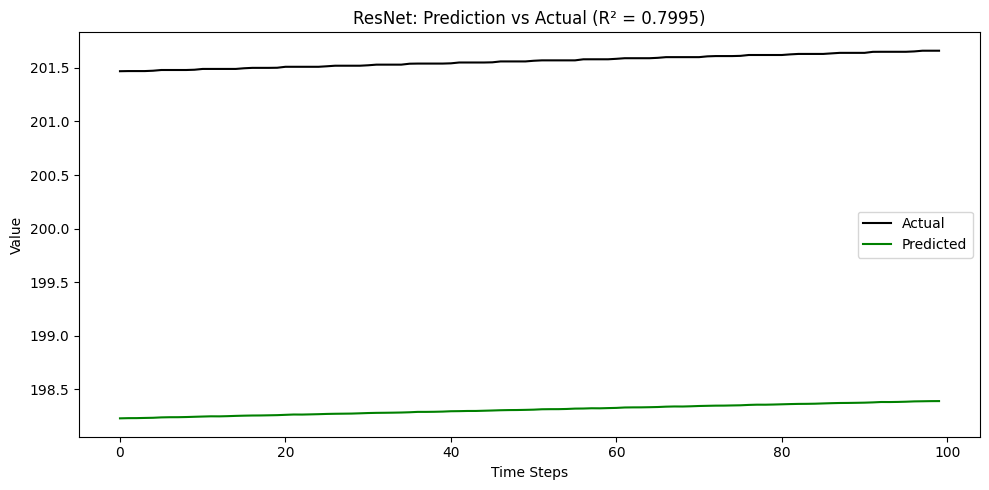

In [ ]:
# --- Line Plot of Prediction ---
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[:100], label='Actual', color='black')
plt.plot(y_pred_inv[:100], label='Predicted', color='green')
plt.title(f"ResNet: Prediction vs Actual (R² = {r2:.4f})")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

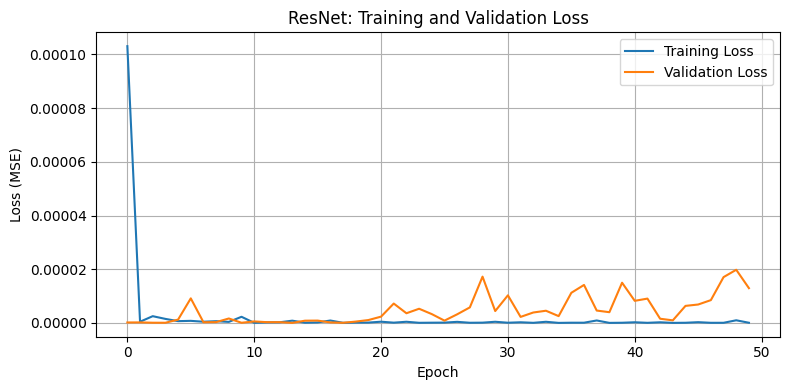

In [ ]:
# --- Training Loss Plot ---
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("ResNet: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()